In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy import stats
from netCDF4 import Dataset, num2date

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, ConvLSTM2D, Conv2D, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')

DATA_DIR  = "data/"
MODEL_DIR = "models/"
os.makedirs(DATA_DIR,  exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

IOD_LAT_MIN, IOD_LAT_MAX = -20, 20
IOD_LON_MIN, IOD_LON_MAX =  40, 120
WEST_POLE = {"lat": (-10, 10), "lon": (50,  70)}
EAST_POLE = {"lat": (-10,  0), "lon": (90, 110)}

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    tf.keras.mixed_precision.set_global_policy('mixed_float16')
    tf.config.optimizer.set_jit(True)
    print(f"✅ GPU ready: {[g.name for g in gpus]} | mixed_float16 + XLA enabled")
else:
    print("⚠️  No GPU detected — running on CPU")

⚠️  No GPU detected — running on CPU


In [2]:
def extract_iod_grid(path):
    nc    = Dataset(path, "r")
    lat   = np.array(nc.variables["lat"][:], dtype=np.float32)
    lon   = np.array(nc.variables["lon"][:], dtype=np.float32)
    sst   = np.ma.filled(nc.variables["sst"][:].astype(np.float32), np.nan)
    t     = nc.variables["time"]
    dates = pd.to_datetime([str(d) for d in num2date(t[:], units=t.units, calendar="standard")])
    nc.close()
    if lon.min() < 0:
        lon = np.where(lon < 0, lon + 360, lon)
    lat_mask = (lat >= IOD_LAT_MIN) & (lat <= IOD_LAT_MAX)
    lon_mask = (lon >= IOD_LON_MIN) & (lon <= IOD_LON_MAX)
    return (sst[:, lat_mask, :][:, :, lon_mask].astype(np.float32),
            lat[lat_mask], lon[lon_mask], dates)

grid, lat, lon, dates = extract_iod_grid(f"{DATA_DIR}sst.mnmean.nc")
print(f"✅ {grid.shape[0]} months | {grid.shape[1]}x{grid.shape[2]} grid | {dates[0].strftime('%Y-%m')} → {dates[-1].strftime('%Y-%m')}")

✅ 2064 months | 21x41 grid | 1854-01 → 2025-12


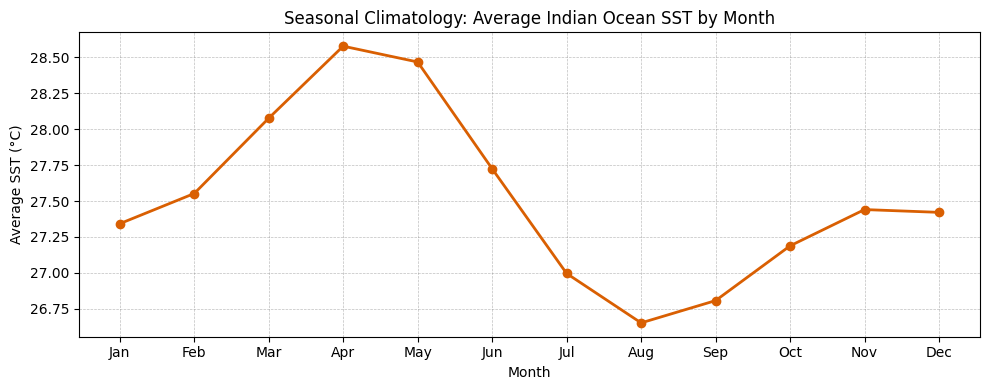

In [3]:
df_sst = pd.DataFrame({'Date': dates, 'SST': np.nanmean(grid, axis=(1, 2))})
df_sst['Month'] = df_sst['Date'].dt.month
df_sst['Year']  = df_sst['Date'].dt.year

climatology = df_sst.groupby('Month')['SST'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(month_names, climatology.values, marker='o', color='#d95f02', linewidth=2)
ax.set(title="Seasonal Climatology: Average Indian Ocean SST by Month", xlabel="Month", ylabel="Average SST (°C)")
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

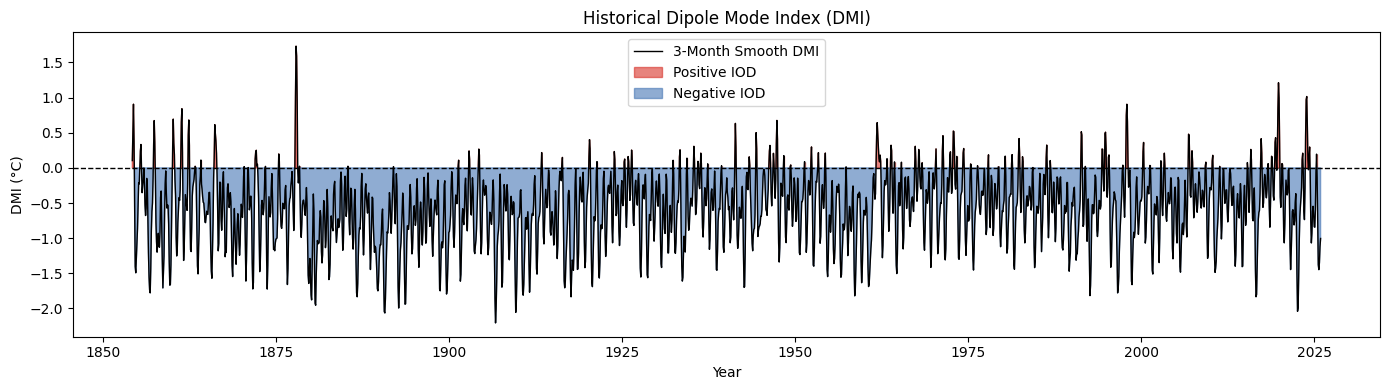

In [4]:
def pole_mask(lat, lon, pole):
    return np.ix_((lat >= pole["lat"][0]) & (lat <= pole["lat"][1]),
                  (lon >= pole["lon"][0]) & (lon <= pole["lon"][1]))

wi, ei = pole_mask(lat, lon, WEST_POLE), pole_mask(lat, lon, EAST_POLE)
dmi_series = (np.nanmean(grid[:, wi[0], wi[1]], axis=(1, 2)) -
              np.nanmean(grid[:, ei[0], ei[1]], axis=(1, 2)))
dmi_smooth = pd.Series(dmi_series).rolling(window=3, center=True).mean()
years_frac  = df_sst['Year'] + df_sst['Month'] / 12

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(years_frac, dmi_smooth, color='black', linewidth=1, label="3-Month Smooth DMI")
ax.fill_between(years_frac, dmi_smooth, 0, where=(dmi_smooth >= 0), color='#d73027', alpha=0.6, label="Positive IOD")
ax.fill_between(years_frac, dmi_smooth, 0, where=(dmi_smooth  < 0), color='#4575b4', alpha=0.6, label="Negative IOD")
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set(title="Historical Dipole Mode Index (DMI)", xlabel="Year", ylabel="DMI (°C)")
ax.legend()
plt.tight_layout()
plt.show()

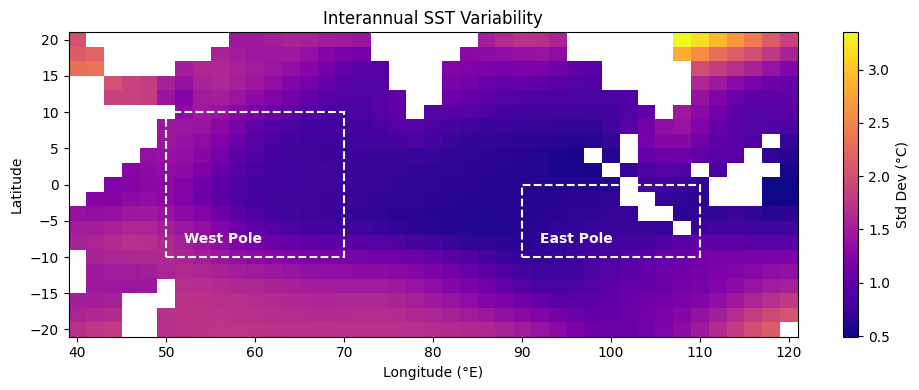

In [5]:
std_map = np.std(grid, axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.pcolormesh(lon, lat, std_map, cmap="plasma", shading="auto")
plt.colorbar(im, ax=ax).set_label("Std Dev (°C)")
for pole, label in [(WEST_POLE, "West Pole"), (EAST_POLE, "East Pole")]:
    ax.add_patch(Rectangle((pole["lon"][0], pole["lat"][0]),
                            pole["lon"][1] - pole["lon"][0], pole["lat"][1] - pole["lat"][0],
                            linewidth=1.5, edgecolor='white', facecolor='none', linestyle='--'))
    ax.text(pole["lon"][0] + 2, pole["lat"][0] + 2, label, color='white', fontsize=10, weight='bold')
ax.set(title="Interannual SST Variability", xlabel="Longitude (°E)", ylabel="Latitude")
plt.tight_layout()
plt.show()

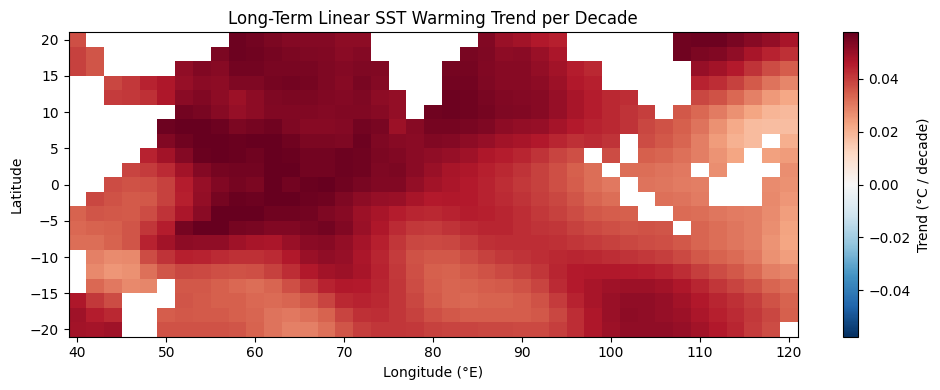

In [6]:
T, H, W = grid.shape
xm   = np.arange(T, dtype=np.float32) - (T - 1) / 2
xvar = (xm ** 2).sum()
trend_decade = ((grid - np.nanmean(grid, axis=0)) * xm[:, None, None]).sum(axis=0) / xvar * 120

vmax = np.abs(np.nanpercentile(trend_decade, [2, 98])).max()
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.pcolormesh(lon, lat, trend_decade, cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto")
plt.colorbar(im, ax=ax).set_label("Trend (°C / decade)")
ax.set(title="Long-Term Linear SST Warming Trend per Decade", xlabel="Longitude (°E)", ylabel="Latitude")
plt.tight_layout()
plt.show()

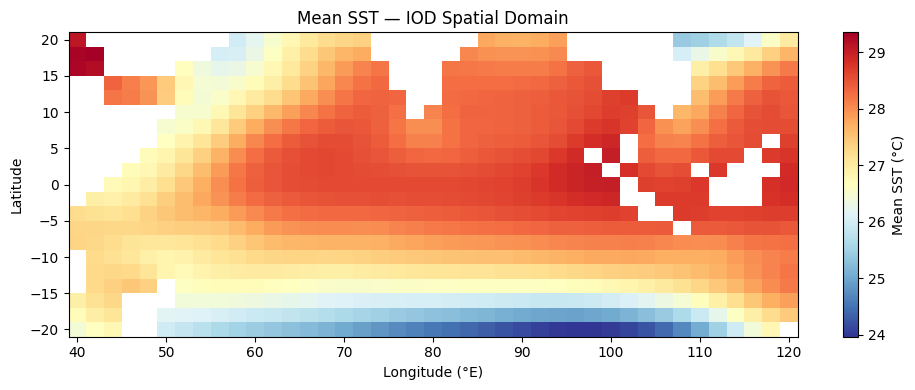

In [7]:
mean_sst = np.nanmean(grid, axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.pcolormesh(lon, lat, mean_sst, cmap="RdYlBu_r", shading="auto")
plt.colorbar(im, ax=ax).set_label("Mean SST (°C)")
ax.set(title="Mean SST — IOD Spatial Domain", xlabel="Longitude (°E)", ylabel="Latitude")
plt.tight_layout()
plt.show()

In [8]:
start_idx    = np.where(df_sst['Year'] >= 1981)[0][0]
grid_modern  = grid[start_idx:]
dates_modern = dates[start_idx:]

grid_small = grid_modern[:, ::2, ::2]
lat_small  = lat[::2]
lon_small  = lon[::2]
T, H, W    = grid_small.shape

flat   = grid_small.reshape(T, H * W)
filled = (pd.DataFrame(flat)
            .interpolate(method='linear', axis=0)
            .ffill().bfill()
            .values.reshape(T, H, W)
            .astype(np.float32))

sc_min = np.nanmin(filled, axis=0)
sc_max = np.nanmax(filled, axis=0)
rng    = np.where(sc_max != sc_min, sc_max - sc_min, 1.0)
# ocean_mask: pixels where rng > 0 are real ocean; land pixels have constant 0
ocean_mask = rng > 0
scaled = np.nan_to_num((filled - sc_min) / rng, nan=0.0)

seq_len        = 12
forecast_steps = 1
n = T - seq_len - forecast_steps + 1

X = np.zeros((n, seq_len, H, W, 1), dtype=np.float32)
y = np.zeros((n,          H, W, 1), dtype=np.float32)
for i in range(n):
    X[i] = scaled[i : i + seq_len, :, :, np.newaxis]
    y[i] = scaled[i + seq_len : i + seq_len + forecast_steps].squeeze(0)[..., np.newaxis]

split_idx = int(n * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
test_dates = dates_modern[seq_len + forecast_steps - 1 + split_idx:]

print(f"✅ Train: {X_train.shape[0]} | Test: {X_test.shape[0]} | Grid: {H}x{W}")

✅ Train: 422 | Test: 106 | Grid: 11x21


In [9]:
def build_convlstm(seq_len, H, W, forecast_steps=1):
    inp = Input(shape=(seq_len, H, W, 1))
    x   = ConvLSTM2D(32, (3, 3), padding='same', return_sequences=True)(inp)
    x   = BatchNormalization()(x)
    x   = Dropout(0.2)(x)
    x   = ConvLSTM2D(16, (3, 3), padding='same', return_sequences=False)(x)
    x   = BatchNormalization()(x)
    x   = Dropout(0.2)(x)
    out = Conv2D(forecast_steps, (1, 1), padding='same', activation='linear', dtype='float32')(x)
    m   = Model(inp, out, name='IOD_ConvLSTM')
    m.compile(optimizer=Adam(1e-3), loss='mse', metrics=['mae'])
    return m

model = build_convlstm(seq_len, H, W, forecast_steps)
model.summary()

Model: "IOD_ConvLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 12, 11, 21, 1)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d (ConvLSTM2D)        │ (None, 12, 11, 21, 32) │        38,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 12, 11, 21, 32) │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 12, 11, 21, 32) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_lstm2d_1 (ConvLSTM2D)      │ (None, 11, 21, 16)     │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 11, 21, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 11, 21, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 11, 21, 1)      │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 66,065 (258.07 KB)

 Trainable params: 65,969 (257.69 KB)

 Non-trainable params: 96 (384.00 B)

Epoch 1/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - loss: 1.0431 - mae: 0.7729 - val_loss: 0.1852 - val_mae: 0.3645 - learning_rate: 0.0010
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 85ms/step - loss: 0.5729 - mae: 0.5544 - val_loss: 0.1436 - val_mae: 0.3194 - learning_rate: 0.0010
Epoch 3/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - loss: 0.4626 - mae: 0.4852 - val_loss: 0.1309 - val_mae: 0.3053 - learning_rate: 0.0010
Epoch 4/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 84ms/step - loss: 0.4034 - mae: 0.4468 - val_loss: 0.1272 - val_mae: 0.3005 - learning_rate: 0.0010
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.3599 - mae: 0.4166 - val_loss: 0.1211 - val_mae: 0.2920 - learning_rate: 0.0010
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 79ms/step - loss: 0.3157 - mae: 0.3883 - val_loss: 0.1294 - val_mae: 0.3020 - learning_rate: 0.0010
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.2824 - mae: 0.3663 - val_loss: 0.1332 - val_mae: 0.3065 - learning_rate: 0.0010
Epoch 8/50
24

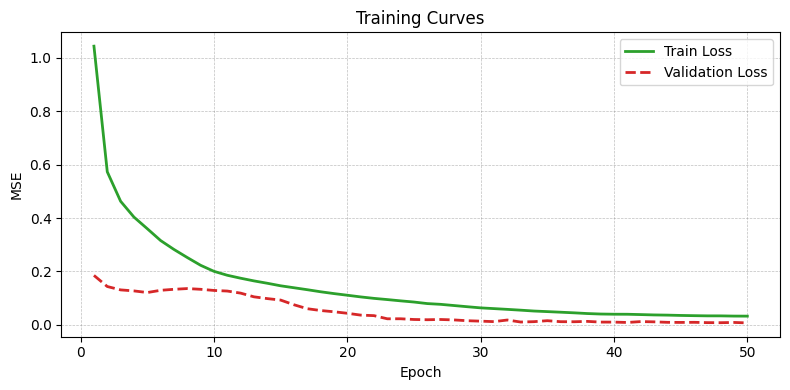

✅ Model saved.


In [10]:
n_val = int(len(X_train) * 0.1)
X_tr, X_val = X_train[:-n_val], X_train[-n_val:]
y_tr, y_val = y_train[:-n_val], y_train[-n_val:]

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

history = model.fit(
    X_tr, y_tr, epochs=50, batch_size=16,
    validation_data=(X_val, y_val), callbacks=callbacks, verbose=1
)

fig, ax = plt.subplots(figsize=(8, 4))
ep = range(1, len(history.history['loss']) + 1)
ax.plot(ep, history.history['loss'],     label='Train Loss',      color='#2ca02c', linewidth=2)
ax.plot(ep, history.history['val_loss'], label='Validation Loss', color='#d62728', linestyle='--', linewidth=2)
ax.set(title='Training Curves', xlabel='Epoch', ylabel='MSE')
ax.legend()
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

model.save(f"{MODEL_DIR}convlstm_iod.keras")
print("✅ Model saved.")

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step
➜ Global RMSE : 0.447 °C
➜ West Pole   : 0.394 °C
➜ East Pole   : 0.383 °C


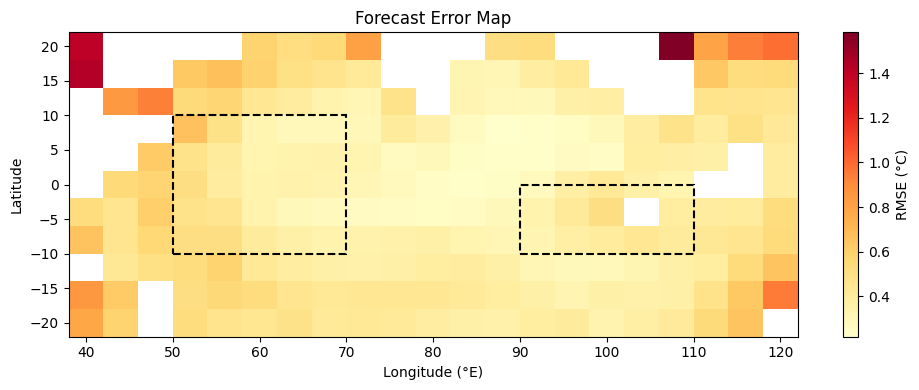

In [11]:
# ── FIX 1: clip predictions to valid scaled range before inverting
y_pred_scaled = np.clip(model.predict(X_test, batch_size=16)[..., 0], 0.0, 1.0)
y_test_scaled = y_test[..., 0]

# ── FIX 2: broadcast (H,W) scaler arrays over batch dim with [np.newaxis]
y_pred = y_pred_scaled * rng[np.newaxis] + sc_min[np.newaxis]
y_true = y_test_scaled * rng[np.newaxis] + sc_min[np.newaxis]

# ── FIX 3: mask land pixels (rng==0) to NaN so they don't corrupt RMSE
y_pred[:, ~ocean_mask] = np.nan
y_true[:, ~ocean_mask] = np.nan

rmse = np.sqrt(np.nanmean((y_pred - y_true) ** 2, axis=0))

wi_s = pole_mask(lat_small, lon_small, WEST_POLE)
ei_s = pole_mask(lat_small, lon_small, EAST_POLE)
print(f"➜ Global RMSE : {np.nanmean(rmse):.3f} °C")
print(f"➜ West Pole   : {np.nanmean(rmse[wi_s]):.3f} °C")
print(f"➜ East Pole   : {np.nanmean(rmse[ei_s]):.3f} °C")

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.pcolormesh(lon_small, lat_small, rmse, cmap='YlOrRd', shading='auto')
plt.colorbar(im, ax=ax).set_label('RMSE (°C)')
for pole in [WEST_POLE, EAST_POLE]:
    ax.add_patch(Rectangle((pole["lon"][0], pole["lat"][0]),
                            pole["lon"][1] - pole["lon"][0], pole["lat"][1] - pole["lat"][0],
                            linewidth=1.5, edgecolor='black', facecolor='none', linestyle='--'))
ax.set(title='Forecast Error Map', xlabel='Longitude (°E)', ylabel='Latitude')
plt.tight_layout()
plt.show()

DMI — Actual: -0.472 °C | Predicted: -1.386 °C


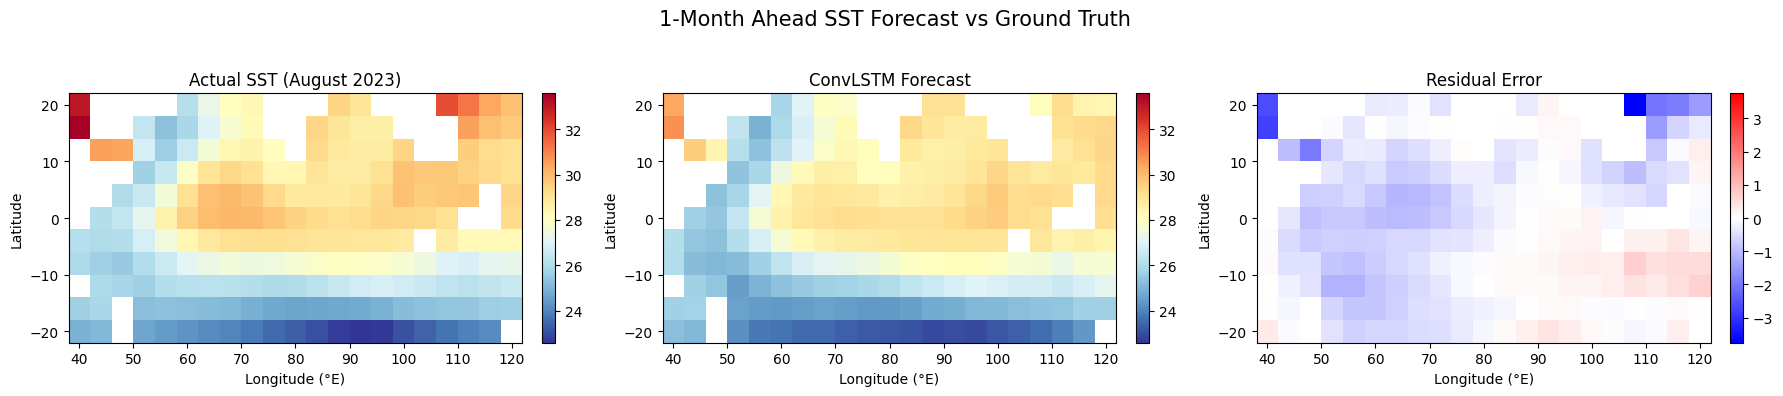

In [12]:
target_month = '2023-08'
date_strings = test_dates.strftime('%Y-%m')
matches = np.where(date_strings == target_month)[0]

if len(matches) == 0:
    print(f"❌ {target_month} not in test set. Range: {date_strings.min()} → {date_strings.max()}")
else:
    idx   = matches[0]
    label = test_dates[idx].strftime('%B %Y')

    dmi_true = np.nanmean(y_true[idx][wi_s]) - np.nanmean(y_true[idx][ei_s])
    dmi_pred = np.nanmean(y_pred[idx][wi_s]) - np.nanmean(y_pred[idx][ei_s])
    print(f"DMI — Actual: {dmi_true:.3f} °C | Predicted: {dmi_pred:.3f} °C")

    vmin     = np.nanmin([y_true[idx], y_pred[idx]])
    vmax     = np.nanmax([y_true[idx], y_pred[idx]])
    residual = y_pred[idx] - y_true[idx]
    abs_max  = np.nanmax(np.abs(residual))

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    im0 = axes[0].pcolormesh(lon_small, lat_small, y_true[idx],  cmap='RdYlBu_r', vmin=vmin,     vmax=vmax,    shading='auto')
    im1 = axes[1].pcolormesh(lon_small, lat_small, y_pred[idx],  cmap='RdYlBu_r', vmin=vmin,     vmax=vmax,    shading='auto')
    im2 = axes[2].pcolormesh(lon_small, lat_small, residual,     cmap='bwr',       vmin=-abs_max, vmax=abs_max, shading='auto')
    axes[0].set_title(f"Actual SST ({label})")
    axes[1].set_title("ConvLSTM Forecast")
    axes[2].set_title("Residual Error")
    for ax, im in zip(axes, [im0, im1, im2]):
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        ax.set_xlabel("Longitude (°E)")
        ax.set_ylabel("Latitude")
    plt.suptitle("1-Month Ahead SST Forecast vs Ground Truth", fontsize=15)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

---
## Extended Analysis

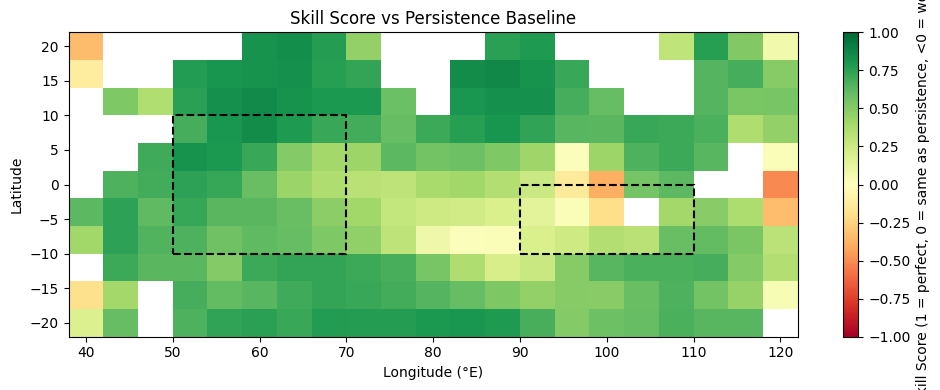

➜ Mean Skill Score (ocean only): 0.541


In [13]:
# ── ANALYSIS 1: Skill Score Map vs Persistence Baseline
# Persistence = predicting next month == current month (last step of each X window)
y_persist = X_test[:, -1, :, :, 0] * rng[np.newaxis] + sc_min[np.newaxis]
y_persist[:, ~ocean_mask] = np.nan

mse_model   = np.nanmean((y_pred - y_true) ** 2, axis=0)
mse_persist = np.nanmean((y_persist - y_true) ** 2, axis=0)
skill_score  = 1.0 - mse_model / np.where(mse_persist > 0, mse_persist, np.nan)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.pcolormesh(lon_small, lat_small, skill_score,
                   cmap='RdYlGn', vmin=-1, vmax=1, shading='auto')
plt.colorbar(im, ax=ax).set_label('Skill Score (1 = perfect, 0 = same as persistence, <0 = worse)')
for pole in [WEST_POLE, EAST_POLE]:
    ax.add_patch(Rectangle((pole["lon"][0], pole["lat"][0]),
                            pole["lon"][1] - pole["lon"][0], pole["lat"][1] - pole["lat"][0],
                            linewidth=1.5, edgecolor='black', facecolor='none', linestyle='--'))
ax.set(title='Skill Score vs Persistence Baseline', xlabel='Longitude (°E)', ylabel='Latitude')
plt.tight_layout()
plt.show()
print(f"➜ Mean Skill Score (ocean only): {np.nanmean(skill_score):.3f}")

DJF: 0.440 °C
MAM: 0.472 °C
JJA: 0.398 °C
SON: 0.444 °C


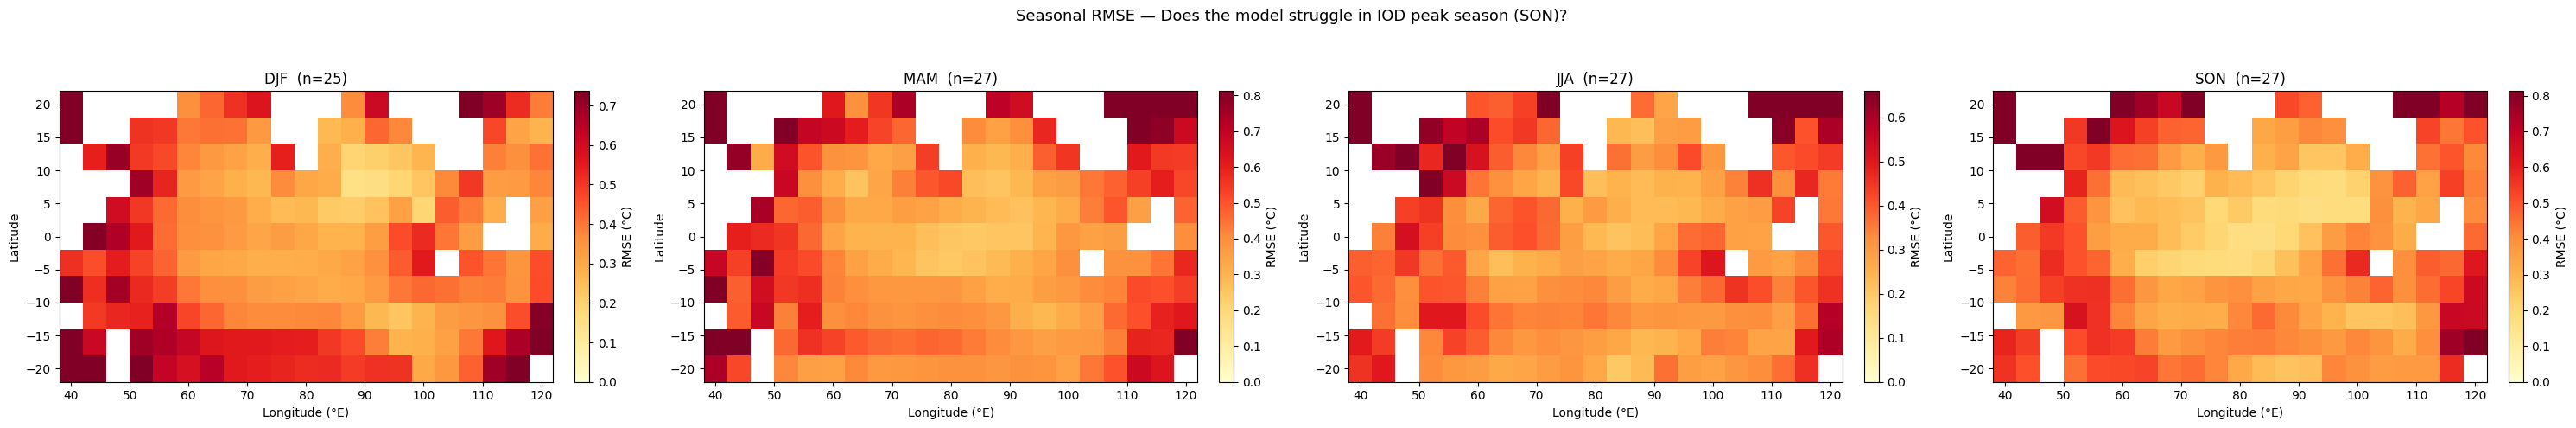

In [27]:
# ── ANALYSIS 2: Seasonal Stratified RMSE
season_map   = {12: 'DJF', 1: 'DJF', 2: 'DJF',
                3: 'MAM', 4: 'MAM', 5: 'MAM',
                6: 'JJA', 7: 'JJA', 8: 'JJA',
                9: 'SON', 10: 'SON', 11: 'SON'}
test_months  = pd.DatetimeIndex(test_dates).month
seasons      = np.array([season_map[m] for m in test_months])
season_order = ['DJF', 'MAM', 'JJA', 'SON']

fig, axes = plt.subplots(1, 4, figsize=(30, 5))
for ax, season in zip(axes, season_order):
    mask = seasons == season
    if mask.sum() == 0:
        continue
    s_rmse = np.sqrt(np.nanmean((y_pred[mask] - y_true[mask]) ** 2, axis=0))
    vmax_s = np.nanpercentile(s_rmse, 95)
    im = ax.pcolormesh(lon_small, lat_small, s_rmse,
                       cmap='YlOrRd', vmin=0, vmax=vmax_s, shading='auto')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04).set_label('RMSE (°C)')
    ax.set_title(f"{season}  (n={mask.sum()})")
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude')
    print(f"{season}: {np.nanmean(s_rmse):.3f} °C")
plt.suptitle('Seasonal RMSE — Does the model struggle in IOD peak season (SON)?', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

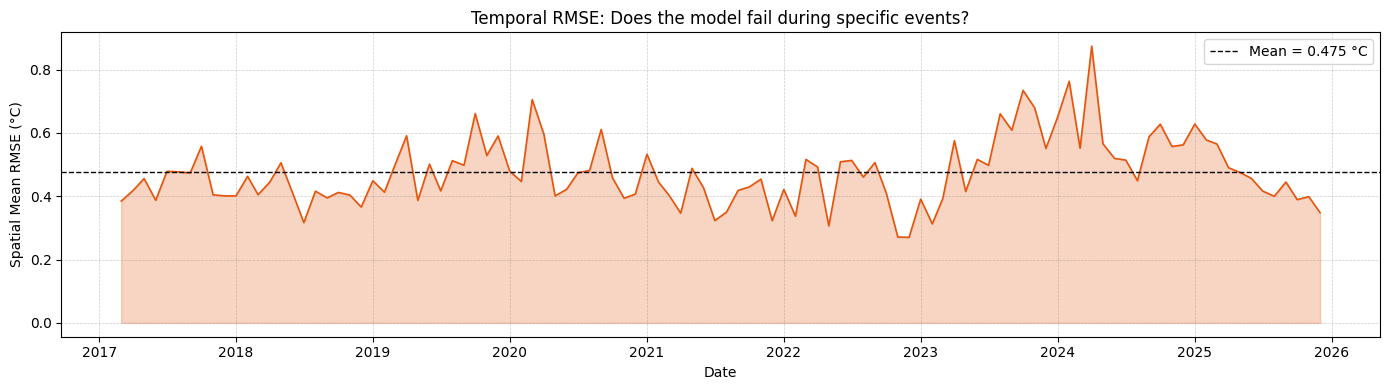

In [15]:
# ── ANALYSIS 3: Temporal RMSE Time Series
temporal_rmse = np.sqrt(np.nanmean((y_pred - y_true) ** 2, axis=(1, 2)))
test_dt = pd.DatetimeIndex(test_dates)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_dt, temporal_rmse, color='#e6550d', linewidth=1.2)
ax.fill_between(test_dt, temporal_rmse, alpha=0.25, color='#e6550d')
ax.axhline(np.nanmean(temporal_rmse), color='black', linestyle='--', linewidth=1, label=f'Mean = {np.nanmean(temporal_rmse):.3f} °C')
ax.set(title='Temporal RMSE: Does the model fail during specific events?',
       xlabel='Date', ylabel='Spatial Mean RMSE (°C)')
ax.legend()
ax.grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.4)
plt.tight_layout()
plt.show()

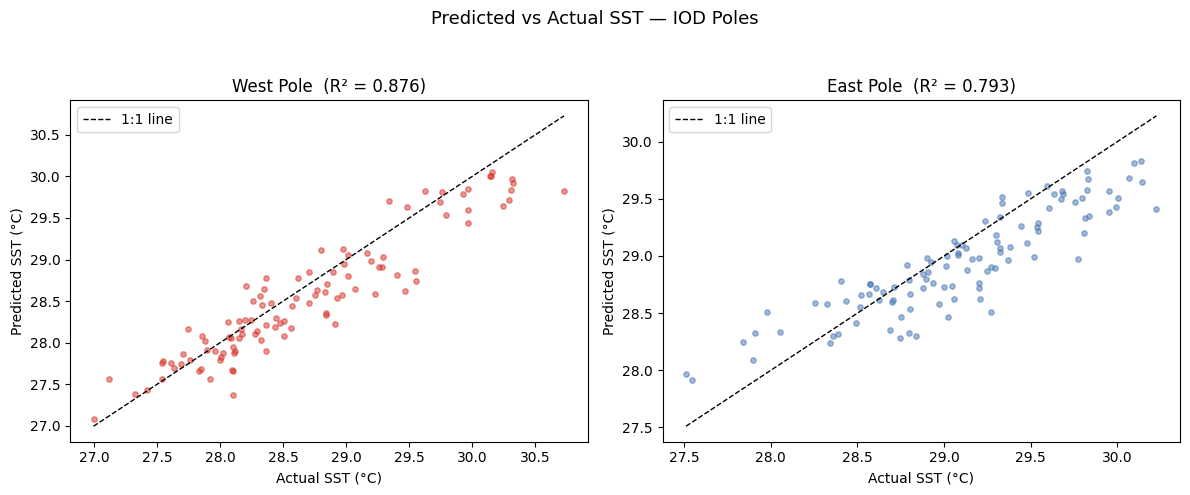

In [16]:
# ── ANALYSIS 4: Predicted vs Actual Scatter (Pole-Averaged)
west_true = np.nanmean(y_true[:, wi_s[0], wi_s[1]], axis=(1, 2))
west_pred = np.nanmean(y_pred[:, wi_s[0], wi_s[1]], axis=(1, 2))
east_true = np.nanmean(y_true[:, ei_s[0], ei_s[1]], axis=(1, 2))
east_pred = np.nanmean(y_pred[:, ei_s[0], ei_s[1]], axis=(1, 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, true_v, pred_v, title, color in [
    (axes[0], west_true, west_pred, 'West Pole', '#d73027'),
    (axes[1], east_true, east_pred, 'East Pole', '#4575b4')
]:
    ax.scatter(true_v, pred_v, alpha=0.5, s=15, color=color)
    lo = min(true_v.min(), pred_v.min())
    hi = max(true_v.max(), pred_v.max())
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, label='1:1 line')
    r2 = stats.pearsonr(true_v, pred_v)[0] ** 2
    ax.set_title(f"{title}  (R² = {r2:.3f})")
    ax.set_xlabel('Actual SST (°C)')
    ax.set_ylabel('Predicted SST (°C)')
    ax.legend()
plt.suptitle('Predicted vs Actual SST — IOD Poles', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

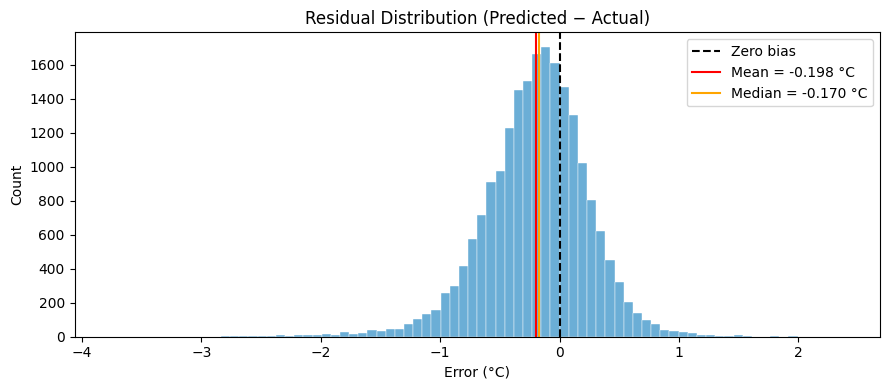

Skewness: -0.589 | Kurtosis: 2.986


In [17]:
# ── ANALYSIS 5: Residual Distribution (Histogram)
ocean_residuals = (y_pred - y_true)[:, ocean_mask].ravel()
ocean_residuals = ocean_residuals[~np.isnan(ocean_residuals)]

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(ocean_residuals, bins=80, color='#6baed6', edgecolor='white', linewidth=0.3)
ax.axvline(0,                           color='black',  linestyle='--', linewidth=1.5, label='Zero bias')
ax.axvline(ocean_residuals.mean(),      color='red',    linestyle='-',  linewidth=1.5, label=f'Mean = {ocean_residuals.mean():.3f} °C')
ax.axvline(np.median(ocean_residuals),  color='orange', linestyle='-',  linewidth=1.5, label=f'Median = {np.median(ocean_residuals):.3f} °C')
ax.set(title='Residual Distribution (Predicted − Actual)', xlabel='Error (°C)', ylabel='Count')
ax.legend()
plt.tight_layout()
plt.show()
print(f"Skewness: {stats.skew(ocean_residuals):.3f} | Kurtosis: {stats.kurtosis(ocean_residuals):.3f}")

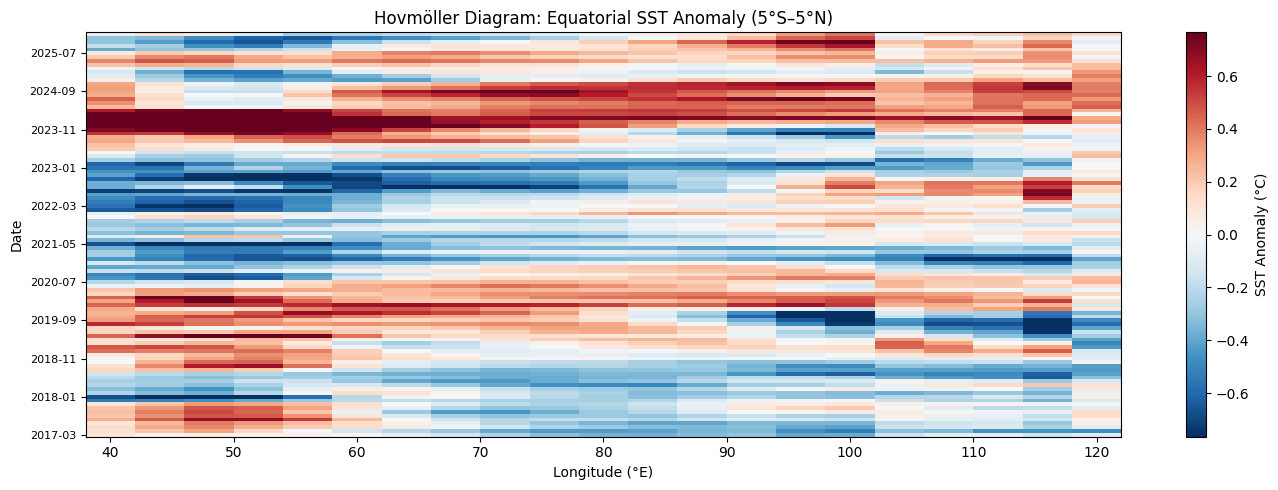

In [18]:
# ── ANALYSIS 6: Hovmöller Diagram (Longitude vs Time, equatorial band)
equatorial = (lat_small >= -5) & (lat_small <= 5)

# SST anomaly = raw - climatological mean per month
true_eq   = y_true[:, equatorial, :]          # (T, eq_lat, lon)
true_eq_m = np.nanmean(true_eq, axis=1)        # (T, lon) — mean over eq latitude band

# Monthly climatology over the test period
test_month_idx = pd.DatetimeIndex(test_dates).month - 1
clim_eq = np.array([true_eq_m[test_month_idx == m].mean(axis=0)
                    if (test_month_idx == m).any() else np.zeros(true_eq_m.shape[1])
                    for m in range(12)])
anom_eq = true_eq_m - clim_eq[test_month_idx]

vlim = np.nanpercentile(np.abs(anom_eq), 97)
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.pcolormesh(lon_small, np.arange(len(test_dates)), anom_eq,
                   cmap='RdBu_r', vmin=-vlim, vmax=vlim, shading='auto')
plt.colorbar(im, ax=ax).set_label('SST Anomaly (°C)')
tick_step = max(1, len(test_dates) // 10)
ax.set_yticks(np.arange(0, len(test_dates), tick_step))
ax.set_yticklabels([test_dates[i].strftime('%Y-%m') for i in range(0, len(test_dates), tick_step)], fontsize=8)
ax.set(title='Hovmöller Diagram: Equatorial SST Anomaly (5°S–5°N)',
       xlabel='Longitude (°E)', ylabel='Date')
plt.tight_layout()
plt.show()

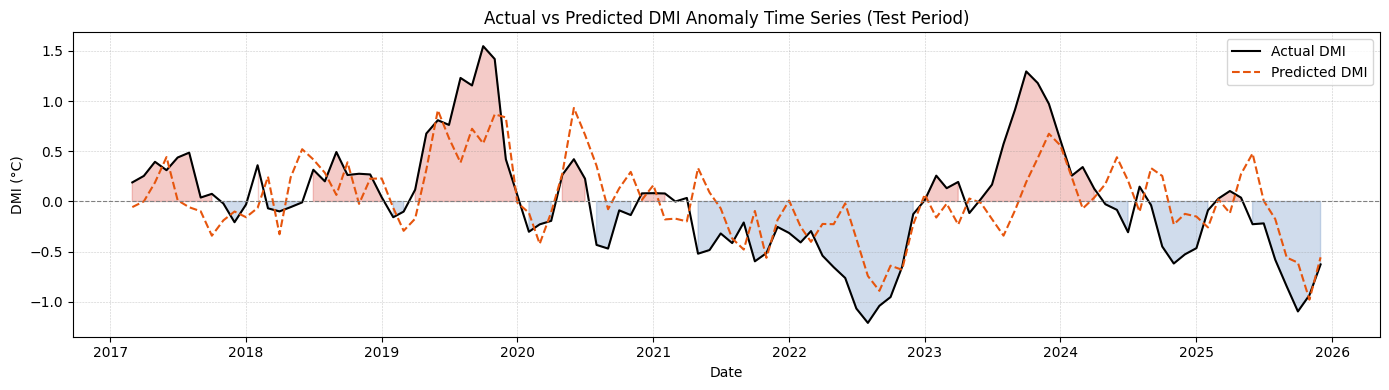

DMI Pearson r = 0.674


In [19]:
# ── ANALYSIS 7: West & East Pole SST Anomaly Time Series + DMI Forecast vs Actual
clim_west = np.array([west_true[pd.DatetimeIndex(test_dates).month == m].mean()
                      if (pd.DatetimeIndex(test_dates).month == m).any() else 0.0
                      for m in range(1, 13)])
clim_east = np.array([east_true[pd.DatetimeIndex(test_dates).month == m].mean()
                      if (pd.DatetimeIndex(test_dates).month == m).any() else 0.0
                      for m in range(1, 13)])

m_idx = pd.DatetimeIndex(test_dates).month - 1
west_anom_true = west_true - clim_west[m_idx]
west_anom_pred = west_pred - clim_west[m_idx]
east_anom_true = east_true - clim_east[m_idx]
east_anom_pred = east_pred - clim_east[m_idx]

dmi_true_ts = west_anom_true - east_anom_true
dmi_pred_ts = west_anom_pred - east_anom_pred

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_dt, dmi_true_ts, color='black',  linewidth=1.5, label='Actual DMI')
ax.plot(test_dt, dmi_pred_ts, color='#e6550d', linewidth=1.5, linestyle='--', label='Predicted DMI')
ax.fill_between(test_dt, dmi_true_ts, 0, where=(dmi_true_ts >= 0), color='#d73027', alpha=0.25)
ax.fill_between(test_dt, dmi_true_ts, 0, where=(dmi_true_ts  < 0), color='#4575b4', alpha=0.25)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set(title='Actual vs Predicted DMI Anomaly Time Series (Test Period)',
       xlabel='Date', ylabel='DMI (°C)')
ax.legend()
ax.grid(color='gray', linestyle='--', linewidth=0.4, alpha=0.4)
plt.tight_layout()
plt.show()

r_dmi = stats.pearsonr(dmi_true_ts, dmi_pred_ts)[0]
print(f"DMI Pearson r = {r_dmi:.3f}")

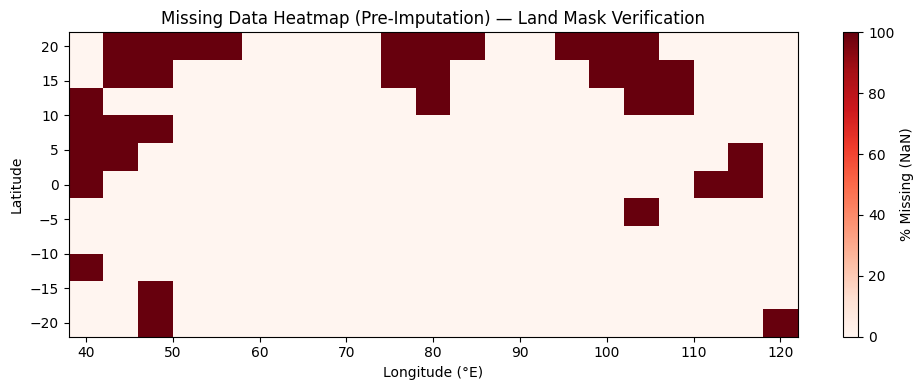

Ocean pixels with 0% missing : 196
Pixels with >90% missing (land): 35


In [20]:
# ── ANALYSIS 8: Missing Data Heatmap (pre-imputation)
nan_frac = np.isnan(grid_small).mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.pcolormesh(lon_small, lat_small, nan_frac * 100,
                   cmap='Reds', vmin=0, vmax=100, shading='auto')
plt.colorbar(im, ax=ax).set_label('% Missing (NaN)')
ax.set(title='Missing Data Heatmap (Pre-Imputation) — Land Mask Verification',
       xlabel='Longitude (°E)', ylabel='Latitude')
plt.tight_layout()
plt.show()
print(f"Ocean pixels with 0% missing : {(nan_frac == 0).sum()}")
print(f"Pixels with >90% missing (land): {(nan_frac > 0.9).sum()}")

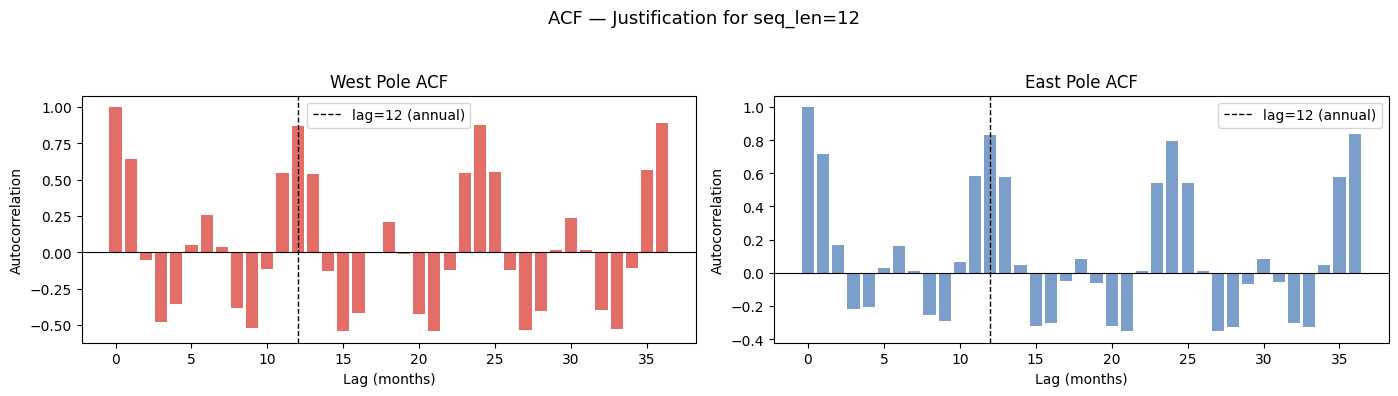

In [21]:
# ── ANALYSIS 9: ACF of West & East Pole SST (justifies seq_len=12)
from pandas.plotting import autocorrelation_plot

west_full = np.nanmean(grid_modern[:, pole_mask(lat_small, lon_small, WEST_POLE)[0],
                                       pole_mask(lat_small, lon_small, WEST_POLE)[1]], axis=(1, 2))
east_full = np.nanmean(grid_modern[:, pole_mask(lat_small, lon_small, EAST_POLE)[0],
                                       pole_mask(lat_small, lon_small, EAST_POLE)[1]], axis=(1, 2))

max_lag = 36
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, series, title, color in [
    (axes[0], west_full, 'West Pole ACF', '#d73027'),
    (axes[1], east_full, 'East Pole ACF', '#4575b4')
]:
    acf_vals = [pd.Series(series).autocorr(lag=l) for l in range(max_lag + 1)]
    ax.bar(range(max_lag + 1), acf_vals, color=color, alpha=0.7)
    ax.axhline(0, color='black', linewidth=0.8)
    ax.axvline(12, color='black', linestyle='--', linewidth=1, label='lag=12 (annual)')
    ax.set(title=title, xlabel='Lag (months)', ylabel='Autocorrelation')
    ax.legend()
plt.suptitle('ACF — Justification for seq_len=12', fontsize=13)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

Initializing Autoregressive Forecast Engine...
➜ Target: August 2028 (32 months into the future)
➜ Running forecast loop................................
✅ Forecast generated!


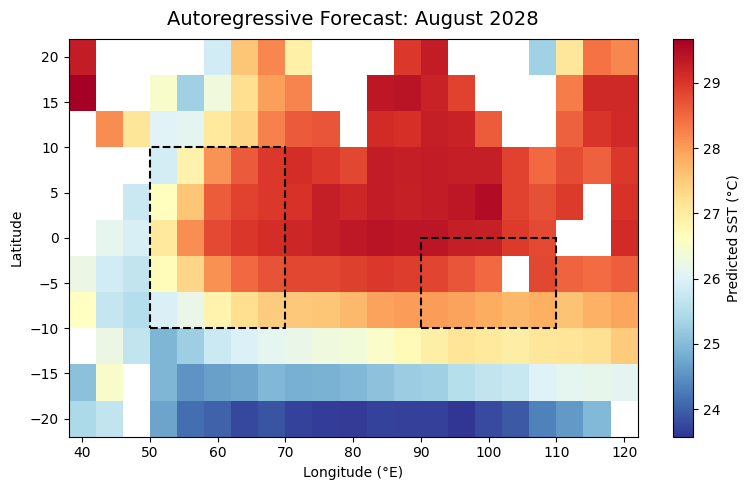

➜ Forecasted DMI for August 2028: -0.797 °C


In [30]:
# ==========================================
# CELL 22: AUTOREGRESSIVE FUTURE FORECASTING
# ==========================================

print("Initializing Autoregressive Forecast Engine...")

# 1. ENTER YOUR DESIRED FUTURE MONTH HERE (Format: 'YYYY-MM')
target_future_month = '2028-08'

# 2. Calculate how many months ahead we need to predict
target_date = pd.to_datetime(target_future_month)
last_known_date = pd.to_datetime(dates_modern[-1])

months_ahead = (target_date.year - last_known_date.year) * 12 + (target_date.month - last_known_date.month)

if months_ahead <= 0:
    print(f"❌ Error: The date {target_future_month} is not in the future. The last known data is {last_known_date.strftime('%B %Y')}.")
else:
    print(f"➜ Target: {target_date.strftime('%B %Y')} ({months_ahead} months into the future)")
    
    # 3. Grab the most recent 12 months of scaled data
    # Shape: (12, H, W)
    current_sequence = scaled[-seq_len:] 
    
    # Reshape for the model: (1, 12, H, W, 1)
    current_sequence = current_sequence[np.newaxis, ..., np.newaxis]
    
    # 4. The Autoregressive Loop
    print("➜ Running forecast loop", end="")
    for step in range(months_ahead):
        print(".", end="") # Progress indicator
        
        # Predict the next single month. Shape: (1, H, W, 1)
        next_step_pred = model.predict(current_sequence, verbose=0)
        
        # Optional but recommended: Clip predictions to [0, 1] to prevent runaway drift
        next_step_pred = np.clip(next_step_pred, 0.0, 1.0)
        
        # Reshape prediction to (1, 1, H, W, 1) so we can append it to the time axis
        next_step_pred_expanded = np.expand_dims(next_step_pred, axis=1)
        
        # Slide the window: Drop the oldest month (index 0), append the new prediction
        current_sequence = np.concatenate([current_sequence[:, 1:, ...], next_step_pred_expanded], axis=1)
    
    print("\n✅ Forecast generated!")
    
    # 5. Extract the final predicted month and inverse scale it
    # The final prediction is now the last item in our sequence
    final_pred_scaled = current_sequence[0, -1, ..., 0] 
    
    # Convert back to actual Celsius
    future_pred_celsius = final_pred_scaled * rng + sc_min
    future_pred_celsius[~ocean_mask] = np.nan # Mask out land
    
    # 6. Plot the Future Forecast
    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.pcolormesh(lon_small, lat_small, future_pred_celsius, cmap='RdYlBu_r', shading='auto')
    plt.colorbar(im, ax=ax).set_label('Predicted SST (°C)')
    
    ax.set_title(f"Autoregressive Forecast: {target_date.strftime('%B %Y')}", fontsize=14, pad=10)
    ax.set_xlabel('Longitude (°E)')
    ax.set_ylabel('Latitude')
    
    # Overlay the IOD Poles
    for pole, color in [(WEST_POLE, "black"), (EAST_POLE, "black")]:
        ax.add_patch(Rectangle((pole["lon"][0], pole["lat"][0]),
                                pole["lon"][1] - pole["lon"][0], pole["lat"][1] - pole["lat"][0],
                                linewidth=1.5, edgecolor=color, facecolor='none', linestyle='--'))
    
    plt.tight_layout()
    plt.show()
    
    # 7. Calculate forecasted DMI
    pred_west = np.nanmean(future_pred_celsius[wi_s])
    pred_east = np.nanmean(future_pred_celsius[ei_s])
    print(f"➜ Forecasted DMI for {target_date.strftime('%B %Y')}: {pred_west - pred_east:.3f} °C")